# Unit 3: ERP分析原理与实现

## 理论知识

### 3.1 ERP基础概念

事件相关电位（Event-Related Potential, ERP）是指与特定感觉、认知或运动事件在时间上锁定的脑电变化。ERP是从EEG中提取的与特定事件相关的神经活动信号。

**核心原理：信噪比增强**
- EEG信号包含：事件相关信号（ERP）+ 背景脑电活动 + 噪声
- 假设：ERP在每次trial中是时间锁定的（time-locked），而背景活动和噪声是随机的
- 通过多次trial的平均，随机噪声相互抵消，ERP信号被增强
- 信噪比(SNR)提升与√N成正比（N为trial数量）

### 3.2 ERP成分（Components）

ERP波形由一系列正向（P）和负向（N）偏转组成，根据潜伏期（latency）和极性（polarity）命名：

**感觉诱发电位：**
| 成分 | 潜伏期 | 极性 | 主要脑区 | 功能意义 |
|------|--------|------|----------|----------|
| P1 | 50-100 ms | 正 | 枕叶 | 早期视觉处理 |
| N1 | 100-150 ms | 负 | 颞叶/额叶 | 感觉注意 |
| P2 | 150-200 ms | 正 | 额中央 | 感觉编码 |

**认知相关成分：**
| 成分 | 潜伏期 | 极性 | 主要脑区 | 功能意义 |
|------|--------|------|----------|----------|
| N2 | 200-300 ms | 负 | 额中央 | 冲突监测 |
| P3/P300 | 300-500 ms | 正 | 顶叶 | 上下文更新、注意分配 |
| N400 | 400-600 ms | 负 | 中央顶 | 语义处理 |
| P600 | 500-800 ms | 正 | 顶叶 | 句法处理 |

**听觉特异性成分：**
| 成分 | 潜伏期 | 功能 |
|------|--------|------|
| N100 | ~100 ms | 听觉皮层激活 |
| MMN | 150-250 ms | 变化检测（deviance detection）|

### 3.3 ERP分析流程

**标准流程：**
1. 数据预处理（Unit 2内容）
2. Epoch提取与基线校正
3. 伪迹拒绝
4. 条件平均（计算Evoked对象）
5. ERP可视化（波形图、地形图）
6. 成分测量（幅度、潜伏期）
7. 统计分析

### 3.4 ERP测量指标

**幅度（Amplitude）：**
- 峰值幅度：成分的最大/最小电压值
- 平均幅度：特定时间窗口内的平均电压
- 峰-峰值：两个相邻成分之间的幅度差

**潜伏期（Latency）：**
- 峰值潜伏期：从刺激开始到成分峰值的时间
- 分数面积潜伏期：达到总积分面积的特定百分比的时间

**测量窗口选择：**
- 基于先验知识（文献报道的时间窗口）
- 基于数据驱动（全局场功率GFP峰值）

### 3.5 统计方法

**传统方法：**
- 重复测量方差分析（Repeated Measures ANOVA）
- 在预定义的ROI（感兴趣区域）和时间窗口内进行

**非参数方法：**
- 聚类置换检验（Cluster-based Permutation Test）
- 控制多重比较问题
- 无需预定义ROI和时间窗口

### 3.6 可视化技术

**波形图（Waveform Plot）：**
- 展示ERP随时间的变化
- 通常叠加多个通道或条件

**地形图（Topographic Map）：**
- 展示特定时间点的头皮电位分布
- 帮助识别成分的头皮分布特征

**联合图（Joint Plot）：**
- 结合波形图和地形图
- 同时展示时间和空间信息

**差异波（Difference Wave）：**
- 两个条件ERP的差值
- 突出条件间的差异

## 实践代码

In [32]:
# 导入必要的库
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections import Counter

# 设置MNE日志级别
mne.set_log_level('WARNING')

print("Unit 3: ERP分析原理与实现")
print("=" * 40)

Unit 3: ERP分析原理与实现


### 1. 加载预处理后的数据

In [45]:
# 修改MNE配置，指向本地数据集目录
data_dir = os.path.abspath("../datasets")
os.makedirs(data_dir, exist_ok=True)
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)

# 加载示例数据并完成预处理
sample_data_folder = mne.datasets.sample.data_path()
raw_file = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_filt-0-40_raw.fif'
raw = mne.io.read_raw_fif(raw_file, preload=True)

# 仅保留EEG通道
raw = raw.pick_types(eeg=True, stim=True, eog=True)
# 查看通道数量
print(f"总通道数: {len(raw.ch_names)}")
# 查看通道类型分布
ch_types = raw.get_channel_types(unique=True)
print(f"通道类型: {ch_types}")
# 分别输出每种类别通道的数量
all_ch_types = raw.get_channel_types()
type_counts = Counter(all_ch_types)
for ch_type, count in type_counts.items():
    print(f"{ch_type} 通道数量: {count}")



总通道数: 69
通道类型: ['stim', 'eeg', 'eog']
stim 通道数量: 9
eeg 通道数量: 59
eog 通道数量: 1


In [46]:

# 应用基本预处理流程
# 1. 滤波
raw.filter(l_freq=0.1, h_freq=40, fir_design='firwin', verbose=False)

# 2. 设置平均参考,数据集中已有平均参考通道,无需设置平均参考
# raw.set_eeg_reference(ref_channels='average', projection=True, verbose=False)

# 3. 查找事件
events = mne.find_events(raw, stim_channel='STI 014', verbose=False)
event_dict = {'auditory/left': 1, 'auditory/right': 2,
              'visual/left': 3, 'visual/right': 4}

# 4. 创建epochs
epochs = mne.Epochs(raw, events, event_id=event_dict,
                    tmin=-0.2, tmax=0.8,
                    baseline=(-0.2, 0),
                    reject=dict(eeg=150e-6),
                    preload=True, verbose=False)

print(f"数据加载与预处理完成")
print(f"保留的epochs: {len(epochs)} trials")

数据加载与预处理完成
保留的epochs: 284 trials


### 2. 计算Evoked（平均ERP）

In [120]:
# 为不同条件计算平均ERP
# Evoked对象 = 对多个epochs进行逐点时间平均

# 计算各条件的Evoked，把多次trial平均值作为Evoked对象
evoked_aud_left = epochs['auditory/left'].average()     # average()只提取EEG通道的平均ERP
evoked_aud_right = epochs['auditory/right'].average()   # average()只提取EEG通道的平均ERP
evoked_vis_left = epochs['visual/left'].average()       # average()只提取EEG通道的平均ERP
evoked_vis_right = epochs['visual/right'].average()     # average()只提取EEG通道的平均ERP

print(f"原始通道类型分布: {Counter(epochs.get_channel_types())}")
print(f"平均ERP通道类型分布: {Counter(evoked_aud_left.get_channel_types())}")

# 计算听觉和视觉的总平均
evoked_auditory = mne.combine_evoked(
    [evoked_aud_left, evoked_aud_right],
    weights='nave' # weights: 权重计算方法，'nave'表示根据trial数量加权平均
)                      
evoked_visual = mne.combine_evoked(
    [evoked_vis_left, evoked_vis_right],
    weights='nave'
)

# 查看Evoked对象信息
print("Evoked对象信息:")
# nave 是 Number of Averaged Epochs 的缩写，意思是“被平均的试次数量”
print(f"听觉平均: {evoked_auditory.nave} trials")  # nave表示参与平均的trial数量
print(f"视觉平均: {evoked_visual.nave} trials")    # nave表示参与平均的trial数量
print(f"\n时间范围: [{evoked_auditory.times[0]:.3f}, {evoked_auditory.times[-1]:.3f}] s")
print(f"通道数: {evoked_auditory.data.shape[0]}")

原始通道类型分布: Counter({'eeg': 59, 'stim': 9, 'eog': 1})
平均ERP通道类型分布: Counter({'eeg': 59})
Evoked对象信息:
听觉平均: 142.0 trials
视觉平均: 142.00000000000003 trials

时间范围: [-0.200, 0.799] s
通道数: 59


### 3. ERP可视化

#### 3.1 单通道波形图

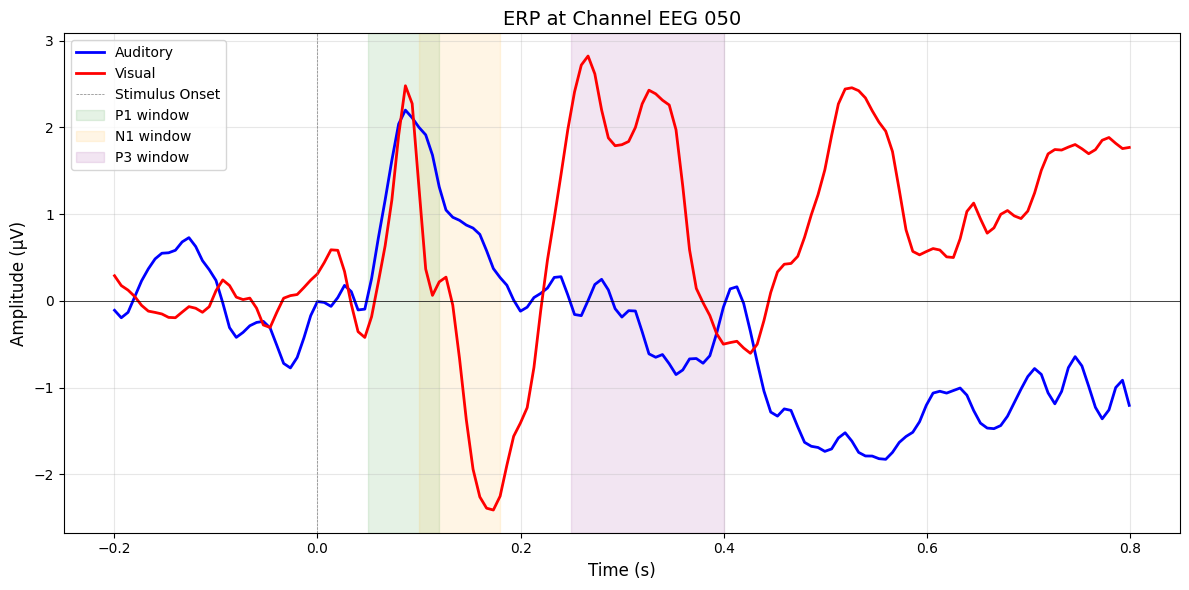

In [54]:
# 选择感兴趣的通道（如中央顶叶通道，常用于观察P300）
roi_channels = ['EEG 052', 'EEG 054', 'EEG 055', 'EEG 060']  # 示例通道

# 绘制听觉和视觉ERP对比
fig, ax = plt.subplots(figsize=(12, 6))

# 选择一个代表性通道
ch_idx = evoked_auditory.ch_names.index('EEG 050')

ax.plot(evoked_auditory.times, evoked_auditory.data[ch_idx] * 1e6, 
        color='blue', linewidth=2, label='Auditory')
ax.plot(evoked_visual.times, evoked_visual.data[ch_idx] * 1e6, 
        color='red', linewidth=2, label='Visual')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, label='Stimulus Onset')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (μV)', fontsize=12)
ax.set_title(f'ERP at Channel EEG 050', fontsize=14)

ax.grid(True, alpha=0.3)

# 标注典型ERP成分的时间窗口
ax.axvspan(0.05, 0.12, alpha=0.1, color='green', label='P1 window')
ax.axvspan(0.10, 0.18, alpha=0.1, color='orange', label='N1 window')
ax.axvspan(0.25, 0.40, alpha=0.1, color='purple', label='P3 window')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

#### 3.2 Joint Plot（波形图 + 地形图）

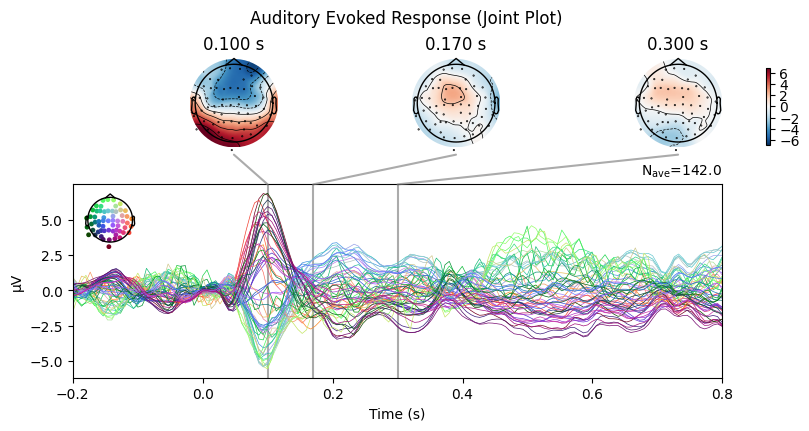

波形图 + 地形图，显示了听觉ERP的平均波形和特定时间点的头皮地形图


In [57]:
# 使用MNE的plot_joint方法
# 同时显示平均波形和特定时间点的头皮地形图

# 选择显示地形图的时间点（通常选择ERP成分的峰值时间）
times = [0.1, 0.17, 0.3]  # P1, N1, P3 的大致时间

evoked_auditory.plot_joint(times=times, 
                           title='Auditory Evoked Response (Joint Plot)',
                           ts_args={'xlim': [-0.2, 0.8]},
                           topomap_args={'size': 2})
plt.show()
print("波形图 + 地形图，显示了听觉ERP的平均波形和特定时间点的头皮地形图")

#### 3.3 多通道叠加图

用标准差来衡量 GFP，本质上是在看所有电极在这一瞬间的“意见分歧”有多大。  
如果所有电极的电压都很接近（比如大家都在 0µV 附近），标准差就小，说明大脑此刻没有强烈的局部活动；反之，如果有的电极电压飙升（正电位），有的暴跌（负电位），标准差就会很大，代表大脑此刻正在发生强烈的局部活动。

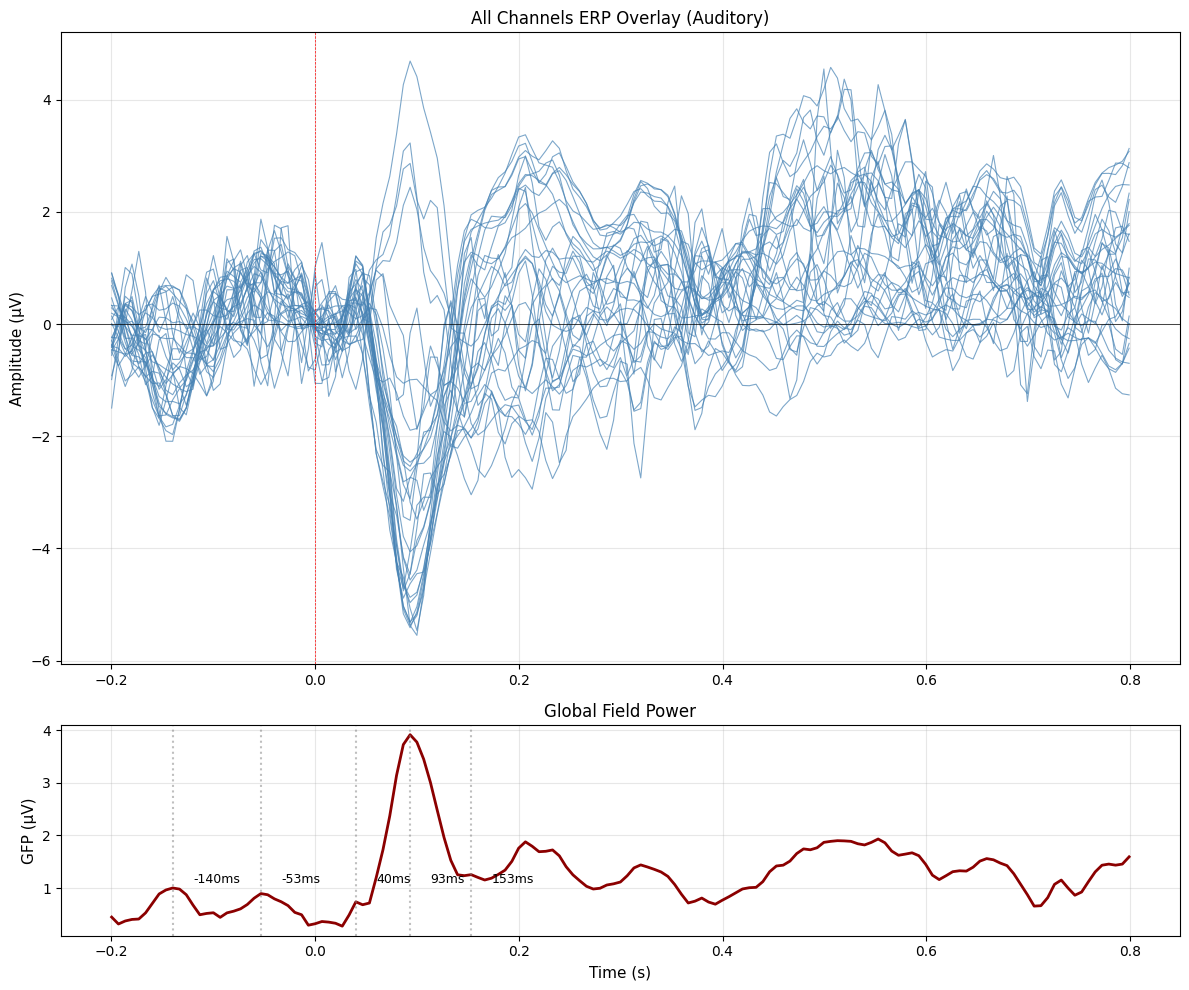

GFP峰值图，显示了听觉ERP的全局场功率峰值时间点
前5个峰值时间点: [-0.13985665 -0.05327872  0.03995904  0.09323777  0.15317633]


In [59]:
# 使用GFP（全局场功率）选择显示时间点
# GFP = 所有通道在某时刻的标准差，反映整体脑电活动强度

gfp = np.std(evoked_auditory.data, axis=0) * 1e6
# gridspec_kw={'height_ratios': [3, 1]}：设置高度比例
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

# 上图：所有通道ERP叠加
for ch_idx, ch_name in enumerate(evoked_auditory.ch_names[:30]):  # 仅显示前30个通道
    ax1.plot(evoked_auditory.times, evoked_auditory.data[ch_idx] * 1e6, 
             linewidth=0.8, alpha=0.7, color='steelblue')

ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=0.5)
ax1.set_ylabel('Amplitude (μV)', fontsize=11)
ax1.set_title('All Channels ERP Overlay (Auditory)', fontsize=12)
ax1.grid(True, alpha=0.3)

# 下图：GFP
ax2.plot(evoked_auditory.times, gfp, color='darkred', linewidth=2)
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_ylabel('GFP (μV)', fontsize=11)
ax2.set_title('Global Field Power', fontsize=12)
ax2.grid(True, alpha=0.3)

# 标记GFP峰值
from scipy.signal import find_peaks
# 找出所有的局部最高点（波峰）
peaks, _ = find_peaks(gfp, distance=evoked_auditory.info['sfreq'] * 0.05)
peak_times = evoked_auditory.times[peaks]
for pt in peak_times[:5]:  # 显示前5个峰值
    ax2.axvline(x=pt, color='gray', linestyle=':', alpha=0.5)
    ax2.annotate(f'{pt*1000:.0f}ms', xy=(pt, gfp[peaks[0]]), 
                 xytext=(pt + 0.02, gfp[peaks[0]] * 1.1),
                 fontsize=9)

plt.tight_layout()
plt.show()
print("GFP峰值图，显示了听觉ERP的全局场功率峰值时间点")
print(f"前5个峰值时间点: {peak_times[:5]}")

### 4. 地形图分析

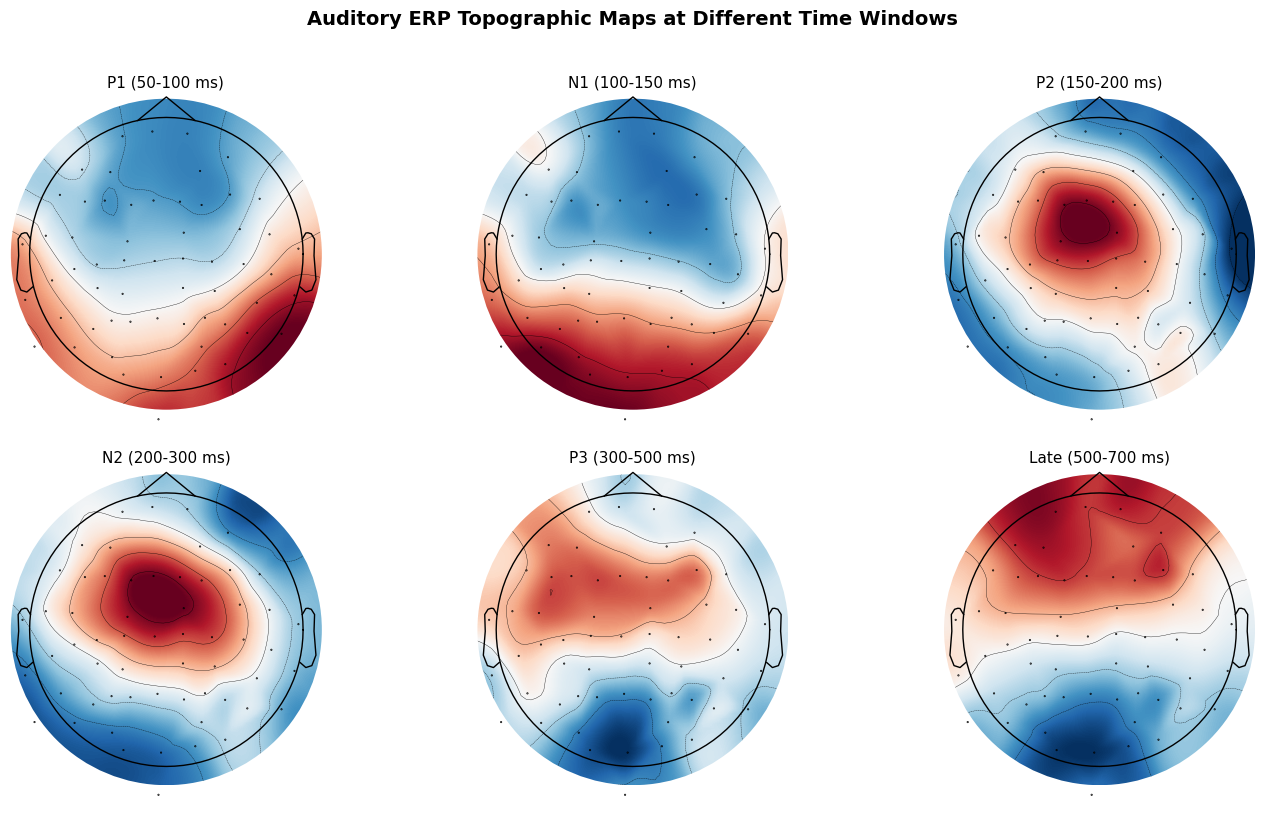

特定时间窗口的平均地形图，显示了听觉ERP在不同时间窗口的平均地形


In [68]:
# 绘制特定时间窗口的平均地形图
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 定义时间窗口
time_windows = [
    (0.05, 0.10, 'P1 (50-100 ms)'),
    (0.10, 0.15, 'N1 (100-150 ms)'),
    (0.15, 0.20, 'P2 (150-200 ms)'),
    (0.20, 0.30, 'N2 (200-300 ms)'),
    (0.30, 0.50, 'P3 (300-500 ms)'),
    (0.50, 0.70, 'Late (500-700 ms)')
]

for ax, (tmin, tmax, title) in zip(axes.flat, time_windows):
    # 计算时间窗口内的平均
    width = tmax - tmin
    evoked_auditory.plot_topomap(times=np.mean([tmin, tmax]), 
                                 axes=ax, show=False,
                                 average=width/2,
                                 colorbar=False) # <--- 添加此行
    ax.set_title(title, fontsize=11)

plt.suptitle('Auditory ERP Topographic Maps at Different Time Windows', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("特定时间窗口的平均地形图，显示了听觉ERP在不同时间窗口的平均地形")

### 5. ERP成分测量

#### 5.1 峰值幅度和潜伏期

In [ ]:
# 测量特定时间窗口内的峰值幅度和潜伏期

def measure_erp_component(evoked, ch_name, time_window, component_name):
    """
    测量ERP特定成分的峰值和潜伏期
    
    参数:
        evoked: Evoked对象
        ch_name: 通道名称
        time_window: 时间窗口 (tmin, tmax)
        component_name: 成分名称
    """
    ch_idx = evoked.ch_names.index(ch_name)
    
    # 提取时间窗口内的数据
    tmask = (evoked.times >= time_window[0]) & (evoked.times <= time_window[1])
    times = evoked.times[tmask]
    data = evoked.data[ch_idx, tmask] * 1e6  # 转换为μV
    
    # 找到峰值
    peak_idx = np.argmax(np.abs(data))     # 时间窗口中的峰值索引
    peak_amplitude = data[peak_idx]        # 时间窗口中的峰值幅度
    peak_latency = times[peak_idx] * 1000  # 时间窗口中的峰值潜伏期
    
    # 判断极性
    polarity = 'Positive (P)' if data[peak_idx] > 0 else 'Negative (N)'
    
    return {
        'component': component_name,
        'channel': ch_name,
        'polarity': polarity,
        'peak_amplitude': peak_amplitude,
        'peak_latency': peak_latency
    }

# 测量听觉ERP的多个成分
ch_of_interest = 'EEG 050'
components = [
    ('P1', (0.05, 0.12)),
    ('N1', (0.10, 0.18)),
    ('P2', (0.15, 0.22)),
    ('P3', (0.25, 0.45))
]

print(f"ERP成分测量 - 通道: {ch_of_interest}\n")
print(f"{'成分':<8} {'极性':<15} {'峰值幅度(μV)':<15} {'潜伏期(ms)':<12}")
print("-" * 50)

for comp_name, t_window in components:
    result = measure_erp_component(evoked_auditory, ch_of_interest, t_window, comp_name)
    print(f"{result['component']:<8} {result['polarity']:<15} "
          f"{result['peak_amplitude']:>10.2f}      {result['peak_latency']:>8.1f}")

ERP成分测量 - 通道: EEG 050

成分       极性              峰值幅度(μV)        潜伏期(ms)     
--------------------------------------------------
P1       Positive (P)          2.20          86.6
N1       Positive (P)          1.91         106.6
P2       Positive (P)          0.84         153.2
P3       Negative (N)         -1.28         446.2


#### 5.2 平均幅度测量

In [70]:
# 计算特定时间窗口内的平均幅度
# 平均幅度比峰值幅度更稳定，受噪声影响更小

def measure_mean_amplitude(evoked, ch_name, time_window):
    """计算时间窗口内的平均幅度"""
    ch_idx = evoked.ch_names.index(ch_name)
    tmask = (evoked.times >= time_window[0]) & (evoked.times <= time_window[1])
    return np.mean(evoked.data[ch_idx, tmask]) * 1e6

# 比较不同条件的平均幅度
time_window_p3 = (0.3, 0.5)  # P3时间窗口

print(f"P3时间窗口 ({time_window_p3[0]*1000:.0f}-{time_window_p3[1]*1000:.0f} ms) 平均幅度:\n")
print(f"{'条件':<20} {'平均幅度(μV)':<15}")
print("-" * 35)

conditions = {
    'Auditory Left': evoked_aud_left,
    'Auditory Right': evoked_aud_right,
    'Visual Left': evoked_vis_left,
    'Visual Right': evoked_vis_right
}

for cond_name, ev in conditions.items():
    amp = measure_mean_amplitude(ev, ch_of_interest, time_window_p3)
    print(f"{cond_name:<20} {amp:>10.2f}")

P3时间窗口 (300-500 ms) 平均幅度:

条件                   平均幅度(μV)       
-----------------------------------
Auditory Left             -0.77
Auditory Right            -0.77
Visual Left                0.13
Visual Right               1.35


### 6. 差异波分析

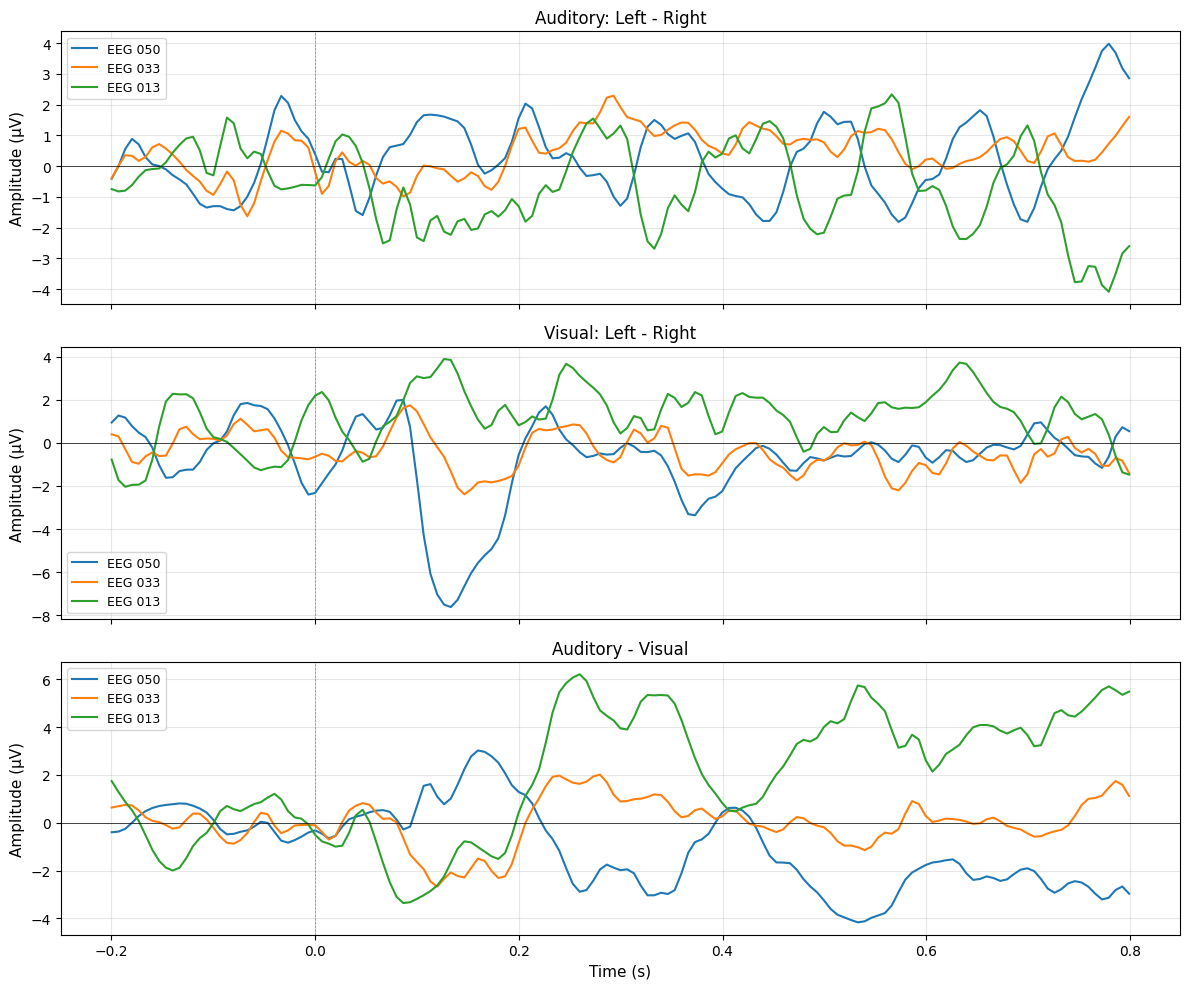

In [72]:
# 计算差异波（Difference Wave）
# 用于突出两个条件之间的差异

# 听觉左 vs 听觉右
# 这行代码生成了一个新的 Evoked 对象 diff_aud，它代表了“左耳刺激减去右耳刺激”后的净效应。
# 你可以像处理普通 ERP 数据一样，对这个差异波绘制地形图或查看波形。
diff_aud = mne.combine_evoked([evoked_aud_left, evoked_aud_right], 
                               weights=[1, -1])

# 视觉左 vs 视觉右
diff_vis = mne.combine_evoked([evoked_vis_left, evoked_vis_right], 
                               weights=[1, -1])

# 感觉模态差异（听觉 - 视觉）
diff_modality = mne.combine_evoked([evoked_auditory, evoked_visual], 
                                    weights=[1, -1])

# 绘制差异波
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

diffs = [
    (diff_aud, 'Auditory: Left - Right', axes[0]),
    (diff_vis, 'Visual: Left - Right', axes[1]),
    (diff_modality, 'Auditory - Visual', axes[2])
]

for ev, title, ax in diffs:
    # 选择几个代表性通道
    for ch_name in ['EEG 050', 'EEG 033', 'EEG 013']:
        ch_idx = ev.ch_names.index(ch_name)
        ax.plot(ev.times, ev.data[ch_idx] * 1e6, linewidth=1.5, label=ch_name)
    
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylabel('Amplitude (μV)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel('Time (s)', fontsize=11)
plt.tight_layout()
plt.show()

### 7. 统计分析

#### 7.1 基于单通道/ROI的t检验

In [ ]:
# 在P3时间窗口内比较听觉和视觉的幅度差异
# 注意：这里使用单受试者数据演示，真实研究需要多受试者数据
time_window_p3 = (0.3, 0.5)  # P3时间窗口

# 计算P3窗口内的trial-by-trial平均幅度
tmin_idx = np.searchsorted(epochs.times, time_window_p3[0]) # P3窗口开始时间索引
tmax_idx = np.searchsorted(epochs.times, time_window_p3[1]) # P3窗口结束时间索引
ch_idx = epochs.ch_names.index(ch_of_interest)

# 提取各trial在P3窗口的平均幅度
# 对时间轴进行平均，得到每个trial在P3窗口的平均幅度
aud_amps = np.mean(epochs['auditory'].get_data()[:, ch_idx, tmin_idx:tmax_idx], axis=1) * 1e6
vis_amps = np.mean(epochs['visual'].get_data()[:, ch_idx, tmin_idx:tmax_idx], axis=1) * 1e6

# 配对样本t检验
# 由于trial数量可能不同，取最小数量进行配对检验
# T:它代表了差异的大小相对于误差（变异）的比率
# p:它代表了差异的显著性水平，通常取0.05或0.01
min_trials = min(len(aud_amps), len(vis_amps))
t_stat, p_value = stats.ttest_rel(aud_amps[:min_trials], vis_amps[:min_trials])

print(f"P3窗口 ({time_window_p3[0]*1000:.0f}-{time_window_p3[1]*1000:.0f} ms) 统计检验")
print(f"通道: {ch_of_interest}")
print(f"\n听觉平均幅度: {np.mean(aud_amps):.2f} μV (SD={np.std(aud_amps):.2f})")
print(f"视觉平均幅度: {np.mean(vis_amps):.2f} μV (SD={np.std(vis_amps):.2f})")
print(f"\nt({min_trials-1}) = {t_stat:.3f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("\n结果: 听觉和视觉在P3窗口存在显著差异 (p < 0.05)")
else:
    print("\n结果: 听觉和视觉在P3窗口无显著差异 (p >= 0.05)")


P3窗口 (300-500 ms) 统计检验
通道: EEG 050

听觉平均幅度: -0.77 μV (SD=4.90)
视觉平均幅度: 0.73 μV (SD=4.65)

t(141) = -2.508, p = 0.0133

结果: 听觉和视觉在P3窗口存在显著差异 (p < 0.05)


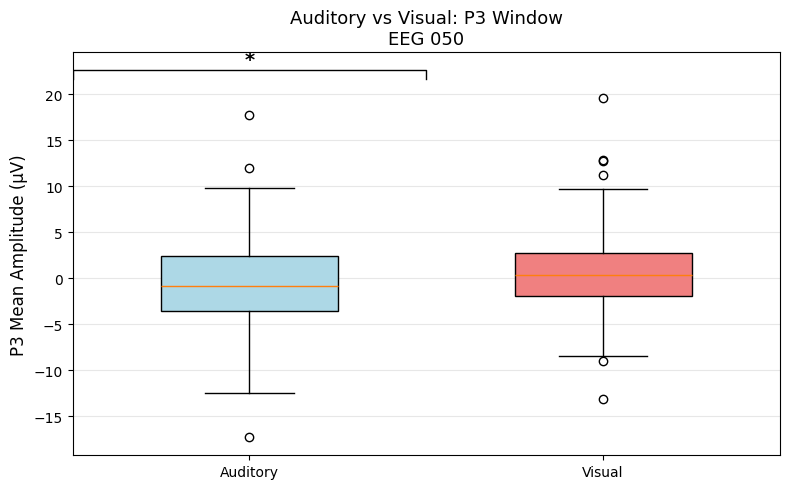

In [77]:

# 1.箱线图可视化
fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [aud_amps, vis_amps]
bp = ax.boxplot(
    data_to_plot,           # 要绘制的数据
    tick_labels=['Auditory', 'Visual'],  # 箱线图标签
    patch_artist=True,      # 是否填充箱体颜色
    widths=0.5              # 箱体宽度
)
colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel(f'P3 Mean Amplitude (μV)', fontsize=12)
ax.set_title(f'Auditory vs Visual: P3 Window\n{ch_of_interest}', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

# 2.添加显著性标注
# aud_amps:只剩trial这个维度
y_max = max(np.max(aud_amps), np.max(vis_amps))
# 顶部添加显著性标注的线
ax.plot([0.5, 0.5, 1.5, 1.5], 
        [y_max * 1.1, y_max * 1.15, y_max * 1.15, y_max * 1.1], 
        color='black', linewidth=1)
# 显著性标注
significance = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'n.s.'
ax.text(1, y_max * 1.18, significance, ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### 7.2 聚类置换检验（Cluster-based Permutation Test）

In [ ]:
# 聚类置换检验：无需预定义ROI和时间窗口的非参数统计方法
# 原理：
# 1. 对每个时间点×通道组合计算统计量（如t值）
# 2. 将相邻的显著样本点聚类
# 3. 通过置换（随机打标签）生成零分布
# 4. 根据零分布评估实际聚类的显著性

# 准备数据：仅使用EEG通道
epochs_aud = epochs['auditory'].pick_types(eeg=True)
epochs_vis = epochs['visual'].pick_types(eeg=True)
# (trials, eeg_channels, time_points)

# 由于trial数量不同，取子集进行演示
min_trials = min(len(epochs_aud), len(epochs_vis))
X1 = epochs_aud[:min_trials].get_data() * 1e6  # 转换为μV
X2 = epochs_vis[:min_trials].get_data() * 1e6

# X1的shape: (trials, eeg_channels, time_points)
# X2的shape: (trials, eeg_channels, time_points)

print(f"聚类置换检验设置:")
print(f"- 条件1 (听觉): {X1.shape[0]} trials")
print(f"- 条件2 (视觉): {X2.shape[0]} trials")
print(f"- 通道数: {X1.shape[1]}")
print(f"- 时间点: {X1.shape[2]}")
print(f"- 时间范围: [{epochs.times[0]:.3f}, {epochs.times[-1]:.3f}] s")

聚类置换检验设置:
- 条件1 (听觉): 142 trials
- 条件2 (视觉): 142 trials
- 通道数: 59
- 时间点: 151
- 时间范围: [-0.200, 0.799] s


In [ ]:
# 运行聚类置换检验
from mne.stats import permutation_cluster_test

# 定义感兴趣的通道邻接矩阵（用于空间聚类）
# 这里使用简化方式，仅基于时间维度聚类
n_permutations = 1024  # 置换次数

print(f"\n运行聚类置换检验 ({n_permutations} permutations)...")
print("这可能需要几分钟...")

T_obs, clusters, cluster_pv, H0 = permutation_cluster_test(
    [X1, X2],                       # 条件1和条件2的数据列表，用于比较
    n_permutations=n_permutations,  # 置换次数，控制统计检验的精度
    threshold=None,                 # 使用默认阈值（p<0.05对应的t值）
    tail=0,                         # 双侧检验
    out_type='mask',                # 输出类型为掩码数组，便于标识显著聚类
    n_jobs=1,                       # 使用的并行作业数，1表示单线程运行
    seed=42,                        # 随机种子，确保结果可重复
    verbose=False                   # 是否显示详细输出信息，False表示静默模式
)
# clusters的shape(n_clusters, n_channels, n_times)


In [98]:

# 输出结果
print(f"\n检验结果:")
print(f"发现 {len(clusters)} 个聚类")
# 遍历每个聚类
for i, (cluster, p_val) in enumerate(zip(clusters, cluster_pv)):
    if p_val < 0.05:
        # cluster的shape(n_channels, n_times)
        sig_marker = "*"
        print(f"聚类 {i+1}: p = {p_val:.4f} {sig_marker}")
        # 获取聚类的时间范围
        # 1. 找出聚类覆盖的所有时间点（只要有一个通道活跃就算）
        active_time_mask = cluster.any(axis=0) 
        # 2. 将布尔掩码转换为实际的时间值
        time_points = epochs.times[active_time_mask]
        # 3. 打印时间范围
        if len(time_points) > 0:
            print(f"  时间范围: [{time_points[0]*1000:.0f}, {time_points[-1]*1000:.0f}] ms")


检验结果:
发现 109 个聚类
聚类 3: p = 0.0010 *
  时间范围: [200, 393] ms
聚类 4: p = 0.0010 *
  时间范围: [433, 799] ms
聚类 43: p = 0.0078 *
  时间范围: [186, 386] ms
聚类 44: p = 0.0117 *
  时间范围: [466, 799] ms
聚类 50: p = 0.0137 *
  时间范围: [60, 246] ms
聚类 63: p = 0.0010 *
  时间范围: [53, 799] ms
聚类 72: p = 0.0264 *
  时间范围: [173, 340] ms


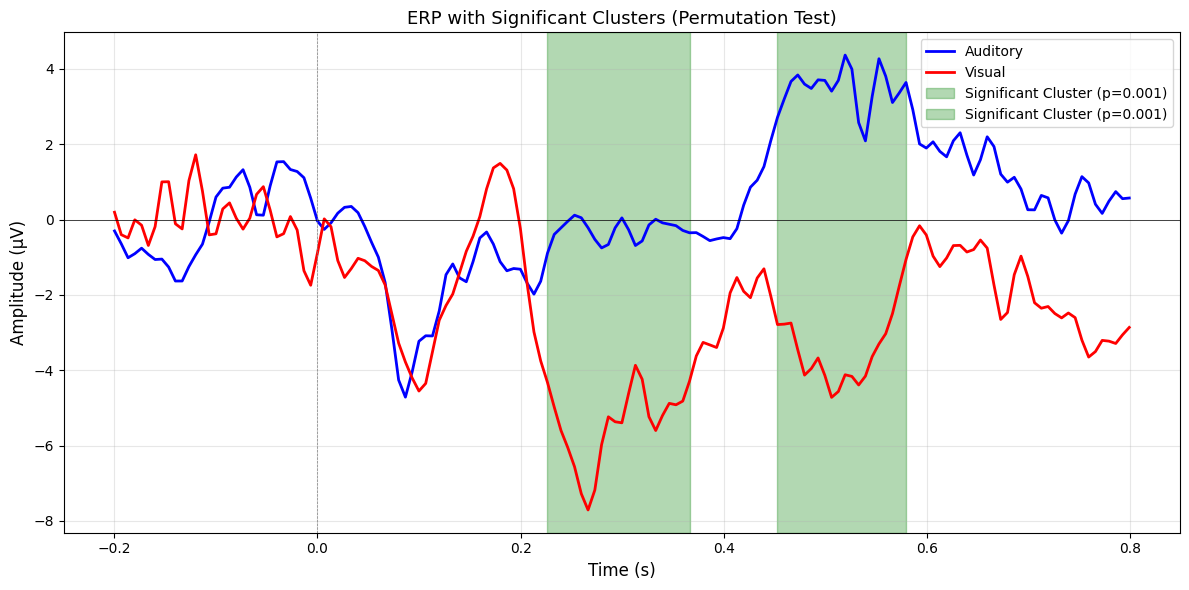

In [99]:
# 可视化聚类检验结果
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制平均ERP
ch_idx = epochs_aud.ch_names.index('EEG 001')
aud_mean = np.mean(X1[:, ch_idx, :], axis=0)
vis_mean = np.mean(X2[:, ch_idx, :], axis=0)

ax.plot(epochs.times, aud_mean, color='blue', linewidth=2, label='Auditory')
ax.plot(epochs.times, vis_mean, color='red', linewidth=2, label='Visual')

# 标记显著聚类
for cluster, p_val in zip(clusters, cluster_pv):
    if p_val < 0.05:
        time_mask = cluster[ch_idx, :]
        time = epochs.times[time_mask]
        if len(time) > 0:
            ax.axvspan(time[0], time[-1], alpha=0.3, color='green', 
                      label=f'Significant Cluster (p={p_val:.3f})')

ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (μV)', fontsize=12)
ax.set_title('ERP with Significant Clusters (Permutation Test)', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8. ERP报告生成

In [100]:
# 生成ERP分析报告摘要

print("=" * 60)
print("ERP 分析报告")
print("=" * 60)

print(f"\n【数据信息】")
print(f"- 采样率: {epochs.info['sfreq']} Hz")
print(f"- 分析通道数: {len(epochs.ch_names)}")
print(f"- Epoch时间窗口: [{epochs.tmin*1000:.0f}, {epochs.tmax*1000:.0f}] ms")

print(f"\n【Trial数量】")
for cond in epochs.event_id.keys():
    print(f"- {cond}: {len(epochs[cond])} trials")


ERP 分析报告

【数据信息】
- 采样率: 150.15374755859375 Hz
- 分析通道数: 69
- Epoch时间窗口: [-200, 799] ms

【Trial数量】
- auditory/left: 71 trials
- auditory/right: 71 trials
- visual/left: 72 trials
- visual/right: 70 trials


In [103]:

print(f"\n【主要ERP成分（通道: {ch_of_interest}）】")
for comp_name, t_window in components:
    result = measure_erp_component(evoked_auditory, ch_of_interest, t_window, comp_name)
    print(f"- {comp_name}: 幅度={result['peak_amplitude']:.2f} μV, "
          f"潜伏期={result['peak_latency']:.1f} ms")

print(f"\n【统计检验结果】")
print(f"- 听觉 vs 视觉 (P3窗口): t={t_stat:.3f}, p={p_value:.4f}")
print(f"- 显著聚类数量: {sum(1 for p in cluster_pv if p < 0.05)}")


# 创建目录
outputs_dir = os.path.abspath("../outputs")
os.makedirs(outputs_dir, exist_ok=True)
# 保存Evoked数据
evoked_auditory.save(os.path.join(outputs_dir, 'auditory-evoked-ave.fif'), overwrite=True)
evoked_visual.save(os.path.join(outputs_dir, 'visual-evoked-ave.fif'), overwrite=True)
print(f"\nEvoked数据已保存到: {outputs_dir}")



【主要ERP成分（通道: EEG 050）】
- P1: 幅度=2.20 μV, 潜伏期=86.6 ms
- N1: 幅度=1.91 μV, 潜伏期=106.6 ms
- P2: 幅度=0.84 μV, 潜伏期=153.2 ms
- P3: 幅度=-1.28 μV, 潜伏期=446.2 ms

【统计检验结果】
- 听觉 vs 视觉 (P3窗口): t=-2.508, p=0.0133
- 显著聚类数量: 7

Evoked数据已保存到: d:\AI\trae_solo\Brain\ERP\outputs


C:\Users\study\AppData\Local\Temp\ipykernel_33600\2435950030.py:17: RuntimeWarning: converting "nave" to integer before saving evoked; this can have a minor effect on the scale of source estimates that are computed using "nave".
  evoked_visual.save(os.path.join(outputs_dir, 'visual-evoked-ave.fif'), overwrite=True)


## 单元小结

**关键知识点回顾：**
1. **ERP原理**：通过trial平均增强信噪比，提取时间锁定的神经响应
2. **ERP成分**：P1、N1、P2、N2、P300等，各有特定的时间窗口和头皮分布
3. **可视化**：波形图、地形图、联合图、差异波
4. **测量指标**：峰值幅度、平均幅度、潜伏期
5. **统计方法**：t检验、ANOVA、聚类置换检验

**分析要点：**
- 测量窗口应基于先验知识或数据驱动（GFP峰值）
- 平均幅度比峰值幅度更稳定
- 聚类置换检验解决了多重比较问题

**下一步学习：**
- Unit 4将学习时频分析方法，探索EEG信号的频率特征随时间的变化

**练习建议：**
1. 尝试不同的ERP成分测量窗口，观察结果的稳定性
2. 比较不同参考方式对ERP波形的影响
3. 对视觉ERP进行与听觉ERP相同的分析流程